<a href="https://colab.research.google.com/github/kosar-am/rice-classification-cnn/blob/main/notebooks/05_pytorch_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rice Image Classification Inference using PyTorch

## Import Required Libraries

In [1]:
import os

import torch
import torch.nn as nn

from torchvision import transforms

from PIL import Image

import matplotlib.pyplot as plt

## Configure Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


## Mount Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Define Project Paths

In [4]:
PROJECT_PATH = "/content/drive/MyDrive/My-Project/Rice-Classification-2026"

MODEL_PATH = os.path.join(PROJECT_PATH, "pytorch", "models")

RESULTS_PATH = os.path.join(PROJECT_PATH, "pytorch", "results")

## Define Image Transformations

In [5]:
image_transform = transforms.Compose([
    transforms.Resize((250, 250)),
    transforms.ToTensor()
])

## Define the Model Architecture

In [8]:
class EfficientCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.pool3 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.global_pool = nn.AdaptiveAvgPool2d(
            output_size=(1, 1)
        )

        self.fc1 = nn.Linear(
            128,
            128
        )

        self.fc2 = nn.Linear(
            128,
            5
        )

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)

        x = torch.relu(self.conv2(x))
        x = self.pool2(x)

        x = torch.relu(self.conv3(x))
        x = self.pool3(x)

        x = self.global_pool(x)

        x = torch.flatten(x, start_dim=1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

## Load the Trained Model

In [9]:
model_file = os.path.join(
    MODEL_PATH,
    "rice_cnn_model2026.pth"
)

model = EfficientCNN()

state_dict = torch.load(
    model_file,
    map_location=device
)

model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


## Load a Test Image

In [10]:
from google.colab import files

uploaded = files.upload()

Saving 11.png to 11.png


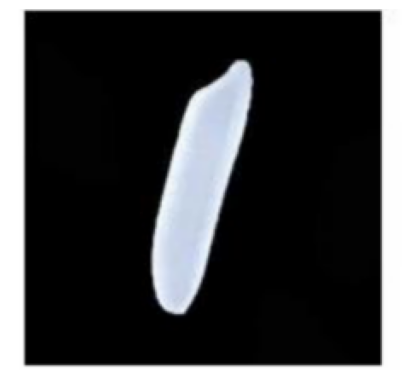

In [11]:
image_path = next(iter(uploaded))

test_image = Image.open(image_path).convert("RGB")

plt.imshow(test_image)
plt.axis("off")
plt.show()

## Predict the Image Class

In [12]:
class_names = [
    "Arborio",
    "Basmati",
    "Ipsala",
    "Jasmine",
    "Karacadag"
]

input_tensor = image_transform(test_image)

input_tensor = input_tensor.unsqueeze(0)

input_tensor = input_tensor.to(device)

with torch.no_grad():
    outputs = model(input_tensor)

    probabilities = torch.softmax(outputs, dim=1)

    predicted_index = torch.argmax(probabilities, dim=1).item()

    predicted_class = class_names[predicted_index]

    confidence = probabilities[0][predicted_index].item() * 100

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

Predicted class: Basmati
Confidence: 100.00%


## Display the Prediction

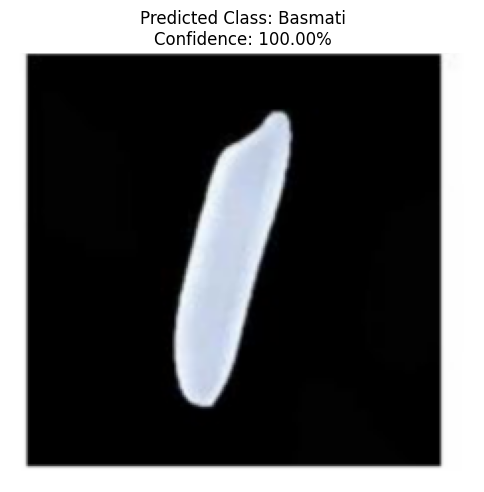

In [13]:
plt.figure(figsize=(6, 6))

plt.imshow(test_image)

plt.title(
    f"Predicted Class: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()